# Webinar 3 — Pipeline Temporal con Boosting y Bagging
**Dataset:** AEP Hourly Energy Consumption

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [16]:
df = pd.read_csv("AEP_hourly.csv", index_col=0, parse_dates=True)
df = df.sort_index()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB


Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       ...
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
      dtype='int32', name='Datetime', length=121273)

In [29]:
df["hora"] = df.index.hour
df["dia_semana"] = df.index.dayofweek
df["mes"] = df.index.month
df["año"] = df.index.year
df["trimestre"] = df.index.quarter
df["dia"] = df.index.day

In [30]:
df.head()

,AEP_MW,hora,dia_semana,mes,año,trimestre,dia
Datetime,,,,,,,
2004-10-01 01:00:00,12379.0,1,4,10,2004,4,1
2004-10-01 02:00:00,11935.0,2,4,10,2004,4,1
2004-10-01 03:00:00,11692.0,3,4,10,2004,4,1
2004-10-01 04:00:00,11597.0,4,4,10,2004,4,1
2004-10-01 05:00:00,11681.0,5,4,10,2004,4,1


## 0. Estacionalidad

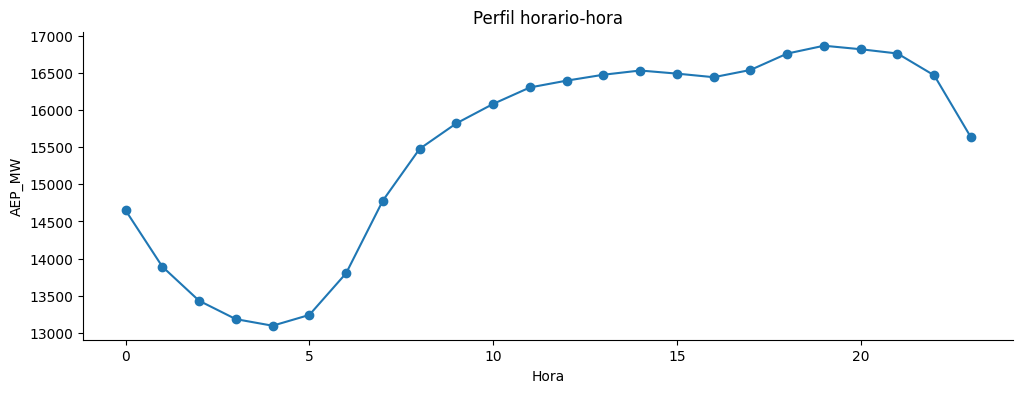

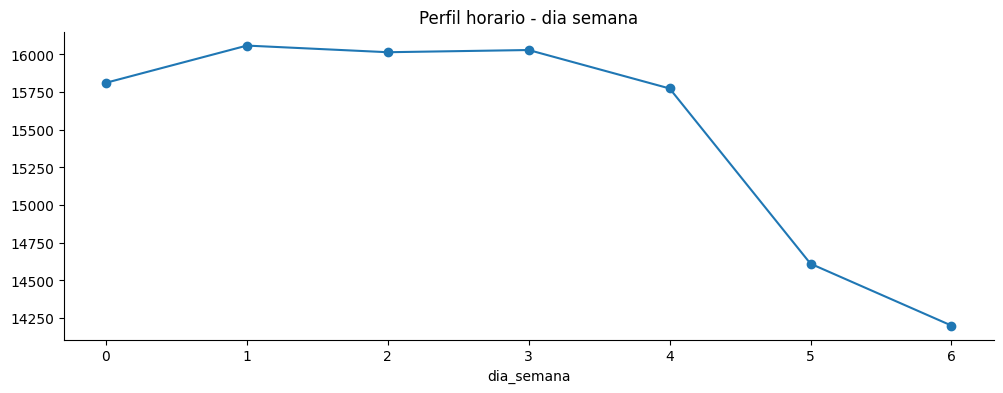

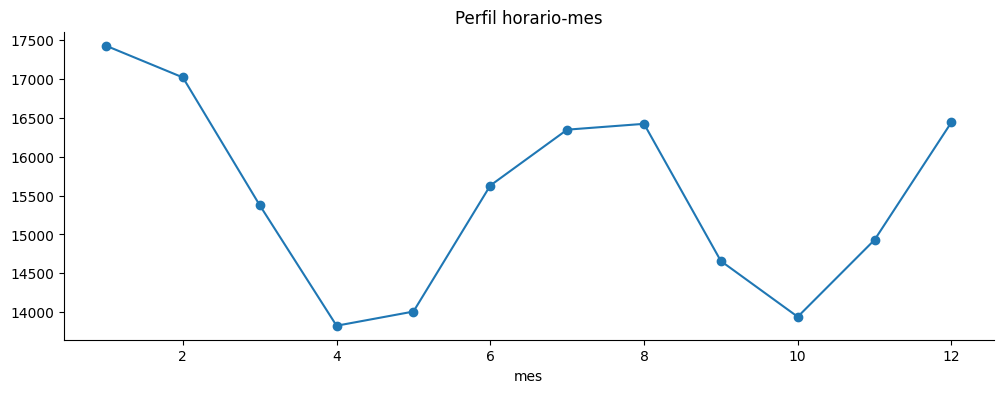

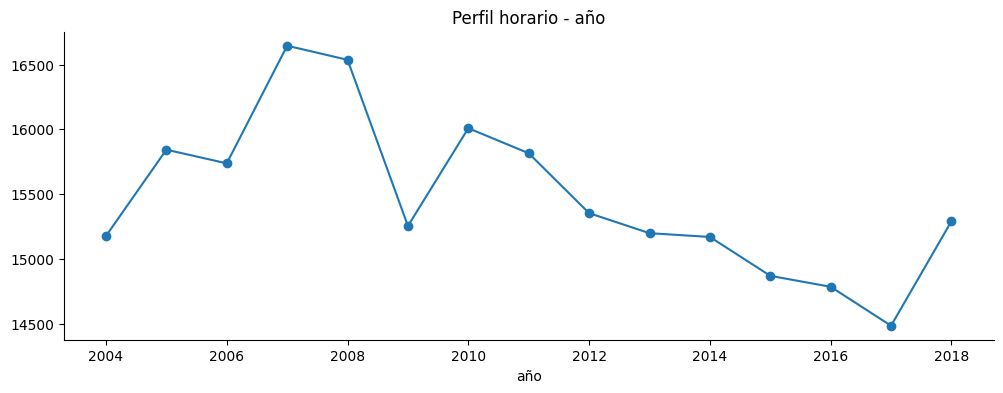

In [39]:
# Perfil horario y semanal
#e
df.groupby("hora")["AEP_MW"].mean().plot(marker="o", title="Perfil horario-hora", xlabel="Hora", ylabel="AEP_MW")
plt.show()

df.groupby("dia_semana")["AEP_MW"].mean().plot(marker="o", title="Perfil horario - dia semana")
plt.show()

df.groupby("mes")["AEP_MW"].mean().plot(marker="o", title="Perfil horario-mes")
plt.show()

df.groupby("año")["AEP_MW"].mean().plot(marker="o", title="Perfil horario - año")
plt.show()

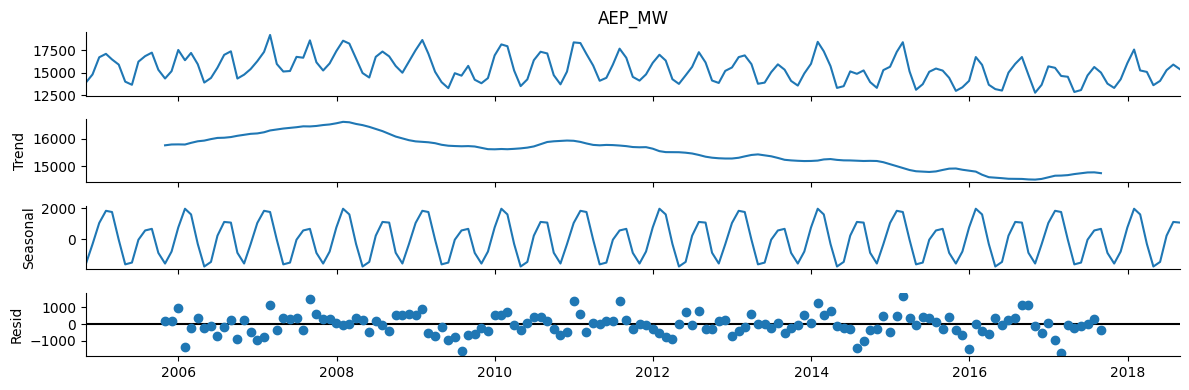

In [ ]:
# Descomposición estacional (diaria, periodo semanal)

seasonal_decompose(df["AEP_MW"].resample("ME").mean(), period=24).plot()
plt.show()


In [ ]:
# Correlación de features con el target
df.corr()


,AEP_MW,hora,dia_semana,mes,año,trimestre,dia
AEP_MW,1.000000,0.419480,-0.219467,-0.125545,-0.175130,-0.134911,-0.006847
hora,0.419480,1.000000,0.000324,-0.000012,-0.000165,-0.000035,-0.000108
dia_semana,-0.219467,0.000324,1.000000,0.000980,-0.000597,0.001325,-0.001230
mes,-0.125545,-0.000012,0.000980,1.000000,-0.093532,0.971527,0.010507
año,-0.175130,-0.000165,-0.000597,-0.093532,1.000000,-0.093063,-0.001892
trimestre,-0.134911,-0.000035,0.001325,0.971527,-0.093063,1.000000,0.012164
dia,-0.006847,-0.000108,-0.001230,0.010507,-0.001892,0.012164,1.000000


<BarContainer object of 169 artists>

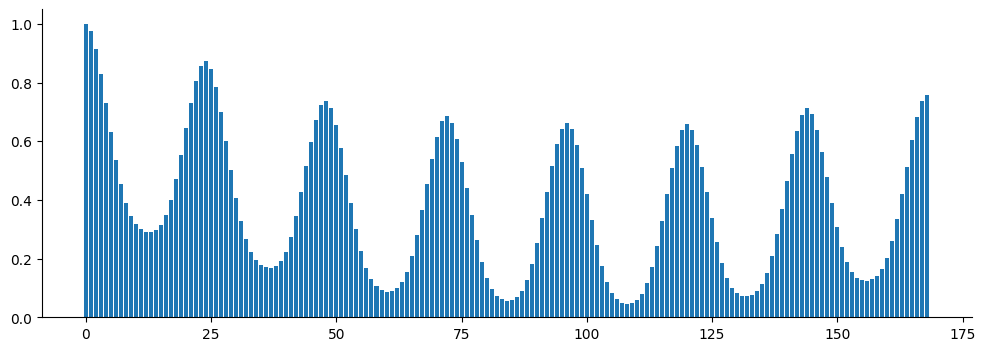

In [49]:
# Autocorrelación 
acf_values = acf(df["AEP_MW"], nlags=168,fft=True)

plt.bar(range(len(acf_values)), acf_values)




## 1. Ingeniería de características

In [55]:
def build_features(df):
    #Creemos diferentes características con los datos ¿Qué propondrías?
    df["hora"] = df.index.hour
    df["dia_semana"] = df.index.dayofweek
    df["es_fin_semana"] = df["dia_semana"].isin([5, 6]).astype(int)
    df["trimeste"] = df.index.quarter

    #lags
    df["lag_h"] = df["AEP_MW"].shift(1)
    df["lag_24h"] = df["AEP_MW"].shift(24)
    df["lag_168h"] = df["AEP_MW"].shift(168)
                                       

    #medias moviles
    df["mm_1h"] = df["AEP_MW"].shift(1).rolling(1).mean()
    df["mm_24h"] = df["AEP_MW"].shift(1).rolling(24).mean()
    df["mm_168h"] = df["AEP_MW"].shift(1).rolling(168).mean()
    df["mstd_24h"] = df["AEP_MW"].shift(1).rolling(24).std()

    return df.dropna()

df = build_features(pd.DataFrame(df["AEP_MW"]))
df.head()

,AEP_MW,hora,dia_semana,es_fin_semana,trimeste,lag_h,lag_24h,lag_168h,mm_1h,mm_24h,mm_168h,mstd_24h
Datetime,,,,,,,,,,,,
2004-10-15 01:00:00,12766.0,1,4,0,4,13564.0,12685.0,12468.0,13564.0,14486.583333,13915.791667,1477.004634
2004-10-15 02:00:00,12159.0,2,4,0,4,12766.0,12203.0,12046.0,12766.0,14489.958333,13917.565476,1472.795522
2004-10-15 03:00:00,11972.0,3,4,0,4,12159.0,11849.0,11749.0,12159.0,14488.125000,13918.238095,1475.790439
2004-10-15 04:00:00,11867.0,4,4,0,4,11972.0,11744.0,11784.0,11972.0,14493.250000,13919.565476,1466.410799
2004-10-15 05:00:00,12021.0,5,4,0,4,11867.0,11976.0,11919.0,11867.0,14498.375000,13920.059524,1456.566505


## 2. Split temporal

Text(0.5, 1.0, 'Train / Test split')

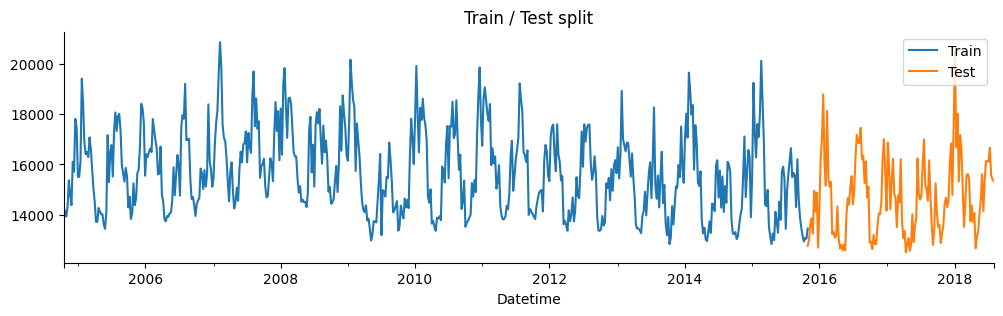

In [59]:
#Realizar el train test
X = df.drop("AEP_MW", axis=1)
y = df["AEP_MW"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 24, shuffle=False)


fig, ax = plt.subplots(figsize=(12, 3))
y_train.resample("W").mean().plot(ax=ax, label="Train")
y_test.resample("W").mean().plot(ax=ax, label="Test")
ax.legend()
ax.set_title("Train / Test split")

## 3. Entrenar y comparar modelos

In [ ]:
model_xg = XGBRegressor()

model_xg.fit(X_train, y_train)
model_xg.predict

param = {
    n_estimators: 100,200, 1000
    criterion : "entropy"


}

In [60]:
models = {
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor(verbosity = -1),
    "Random Forest": RandomForestRegressor()
}

results = {}
predictions = {}

for name,model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = mean_absolute_error(y_test, preds)**0.5


pd.Series(results).sort_values()

Exception in thread Thread-125 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\57304\anaconda3\envs\mi_entorno\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\57304\AppData\Roaming\Python\Python313\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\57304\anaconda3\envs\mi_entorno\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\57304\anaconda3\envs\mi_entorno\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 106: invalid start byte


XGBoost          12.025093
Random Forest    12.030022
LightGBM         12.572130
dtype: float64

In [ ]:
df["AEP_MW"].mean()

# 15503 +- 12.02

np.float64(15503.976954943482)

## 4. Importancia de features (XGBoost)

<Axes: title={'center': 'Importancia de features — XGBoost'}>

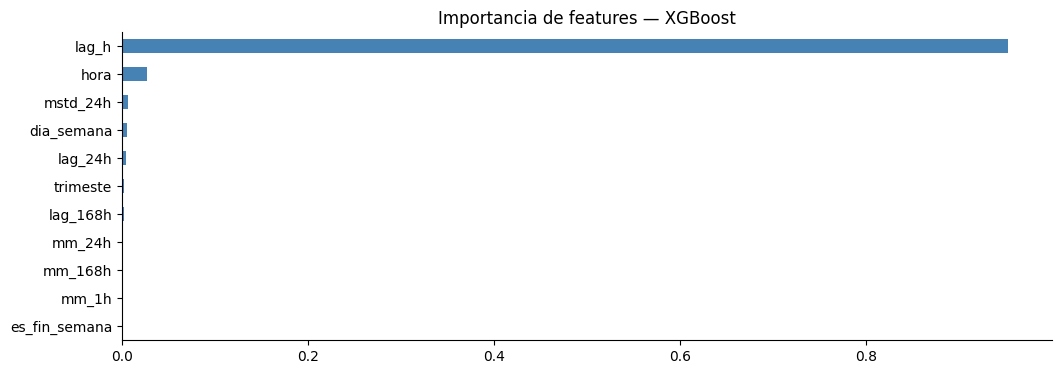

In [62]:
feat_imp = pd.Series(models["XGBoost"].feature_importances_, index=X_train.columns).sort_values()
feat_imp.plot(kind="barh", title="Importancia de features — XGBoost", color="steelblue")

## 5. Visualizar predicciones vs real

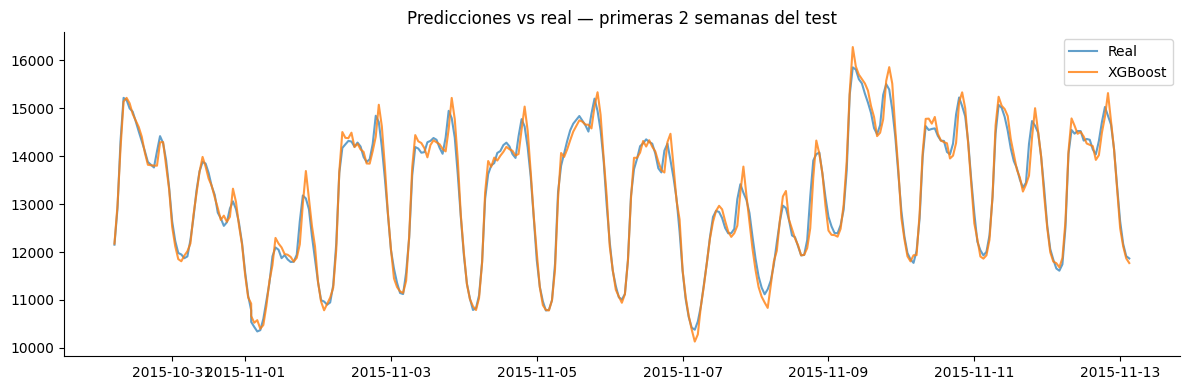

In [66]:
sample = X_test.iloc[:24*14]  # 2 semanas

plt.figure(figsize=(12, 4))
plt.plot(sample.index, y_test.iloc[:24*14], label="Real", alpha=0.7)
plt.plot(sample.index, models["XGBoost"].predict(sample[X_test.columns]),
         label="XGBoost", alpha=0.8)
plt.legend()
plt.title("Predicciones vs real — primeras 2 semanas del test")
plt.tight_layout()